In [4]:
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.float_format", "{:.5f}".format)

In [2]:
train_data = pd.read_parquet("data\\train_data.parquet")
test_data = pd.read_parquet("data\\test_data.parquet")
train_target = pd.read_csv("data\\train_target.csv")

print("Размер train_data:", train_data.shape)
print("Размер test_data:", test_data.shape)
print("Размер train_target:", train_target.shape)

display(train_data.head())
display(test_data.head())
display(train_target.head())

print("Типы данных:")
display(train_data.dtypes.value_counts())

print("Количество уникальных клиентов в train:", train_data["id"].nunique())
print("Количество уникальных клиентов в test:", test_data["id"].nunique())
print("Количество строк на клиента в train:")
display(train_data.groupby("id").size().describe())

Размер train_data: (18317016, 61)
Размер test_data: (7845701, 61)
Размер train_target: (2100000, 2)


,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,2250000,1,4,2,9,12,5,7,6,2,...,3,3,3,4,1,3,5,1,0,0
1,2250000,2,3,17,15,9,15,14,1,2,...,3,3,3,4,1,3,4,1,0,0
2,2250000,3,3,3,16,9,15,14,10,2,...,3,3,3,4,1,3,4,1,0,0
3,2250000,4,11,17,14,7,14,8,9,2,...,3,3,3,4,1,3,4,1,0,0
4,2250000,5,11,6,4,8,1,11,14,2,...,3,3,3,4,1,2,3,1,1,1


,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,2250005,1,3,3,15,9,15,14,1,2,...,3,3,3,4,1,3,4,1,0,0
1,2250005,2,9,2,15,12,1,11,19,6,...,3,3,3,4,1,2,4,1,0,0
2,2250005,3,19,6,16,9,12,11,3,1,...,3,3,3,4,1,2,4,1,0,0
3,2250005,4,19,16,15,9,12,11,12,1,...,3,3,3,4,1,2,4,1,0,0
4,2250013,1,16,7,16,9,4,9,6,2,...,3,3,3,4,1,3,3,1,0,0


,id,flag
0,0,0
1,1,0
2,2,0
3,3,0
4,5,0


Типы данных:


int64    61
Name: count, dtype: int64

Количество уникальных клиентов в train: 2100000
Количество уникальных клиентов в test: 900000
Количество строк на клиента в train:


count   2100000.00000
mean          8.72239
std           6.17441
min           1.00000
25%           4.00000
50%           7.00000
75%          12.00000
max          55.00000
dtype: float64

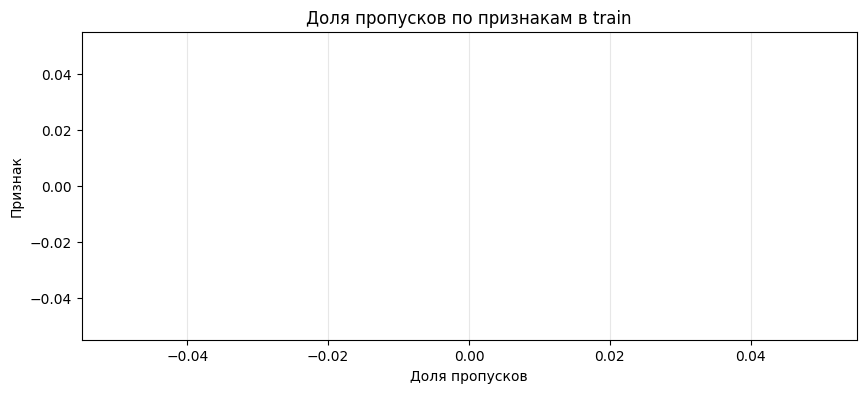

,missing_rate


In [23]:
missing = train_data.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(10, max(4, len(missing) * 0.25)))
plt.barh(missing.index[::-1], missing.values[::-1])
plt.title("Доля пропусков по признакам в train")
plt.xlabel("Доля пропусков")
plt.ylabel("Признак")
plt.grid(axis="x", alpha=0.3)
plt.show()

display(missing.to_frame("missing_rate"))

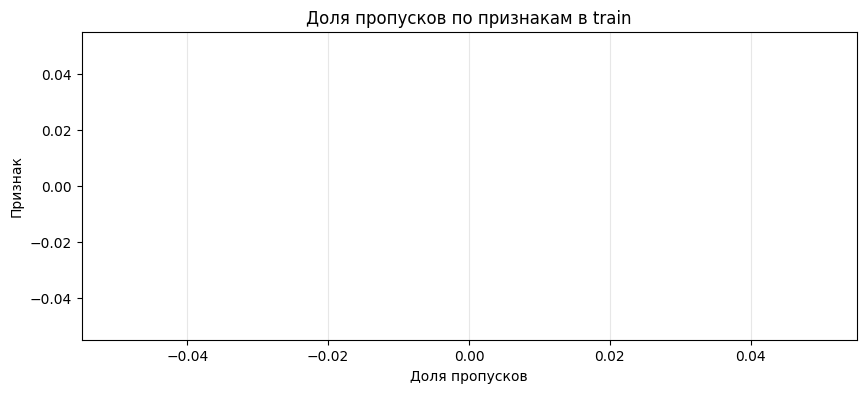

,missing_rate


In [24]:
missing = test_data.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(10, max(4, len(missing) * 0.25)))
plt.barh(missing.index[::-1], missing.values[::-1])
plt.title("Доля пропусков по признакам в train")
plt.xlabel("Доля пропусков")
plt.ylabel("Признак")
plt.grid(axis="x", alpha=0.3)
plt.show()

display(missing.to_frame("missing_rate"))

In [42]:
train_data[train_data["id"] == 2250000]

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,2250000,1,4,2,9,12,5,7,6,2,...,3,3,3,4,1,3,5,1,0,0
1,2250000,2,3,17,15,9,15,14,1,2,...,3,3,3,4,1,3,4,1,0,0
2,2250000,3,3,3,16,9,15,14,10,2,...,3,3,3,4,1,3,4,1,0,0
3,2250000,4,11,17,14,7,14,8,9,2,...,3,3,3,4,1,3,4,1,0,0
4,2250000,5,11,6,4,8,1,11,14,2,...,3,3,3,4,1,2,3,1,1,1
5,2250000,6,2,6,4,8,1,11,3,2,...,3,3,3,4,1,2,4,1,1,1
6,2250000,7,12,2,15,12,12,11,19,6,...,3,3,3,4,1,2,4,1,0,0
7,2250000,8,12,9,6,1,0,4,13,2,...,3,3,3,4,1,2,3,1,0,0


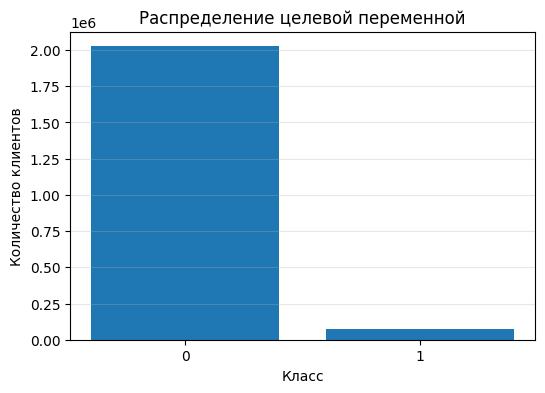

Доля класса 1: 0.03548
Дисбаланс 0/1: 27.18


In [5]:
target_counts = train_target["flag"].value_counts().sort_index()
target_rate = train_target["flag"].mean()

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Распределение целевой переменной")
plt.xlabel("Класс")
plt.ylabel("Количество клиентов")
plt.grid(axis="y", alpha=0.3)
plt.show()

print(f"Доля класса 1: {target_rate:.5f}")
print(f"Дисбаланс 0/1: {(1 - target_rate) / target_rate:.2f}")

In [18]:
train_seq_len > 30

id
0          False
1          False
2          False
3          False
5          False
           ...  
2999995    False
2999996    False
2999997    False
2999998    False
2999999    False
Length: 2100000, dtype: bool

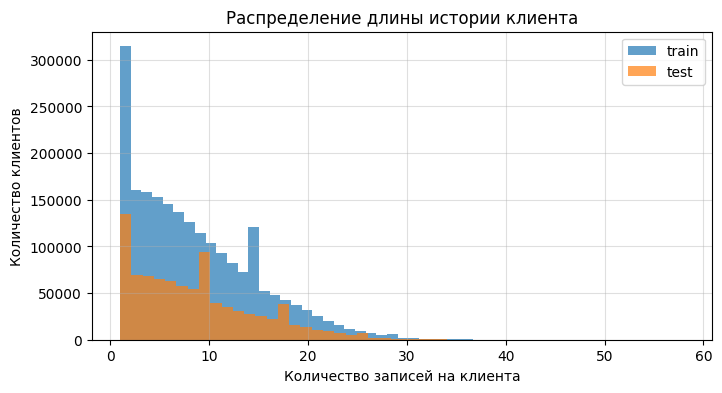

Train длина истории:


count   2100000.00000
mean          8.72239
std           6.17441
min           1.00000
25%           4.00000
50%           7.00000
75%          12.00000
max          55.00000
dtype: float64

Test длина истории:


count   900000.00000
mean         8.71745
std          6.18053
min          1.00000
25%          4.00000
50%          7.00000
75%         12.00000
max         58.00000
dtype: float64

In [20]:
train_seq_len = train_data.groupby("id").size()
test_seq_len = test_data.groupby("id").size()

plt.figure(figsize=(8, 4))
plt.hist(train_seq_len, bins=50, alpha=0.7, label="train")
plt.hist(test_seq_len, bins=50, alpha=0.7, label="test")
plt.title("Распределение длины истории клиента")
plt.xlabel("Количество записей на клиента")
plt.ylabel("Количество клиентов")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

print("Train длина истории:")
display(train_seq_len.describe())

print("Test длина истории:")
display(test_seq_len.describe())

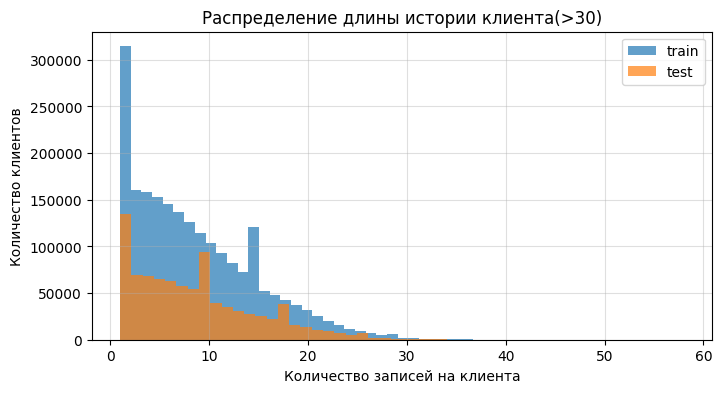

Train длина истории:


count   2100000.00000
mean          8.72239
std           6.17441
min           1.00000
25%           4.00000
50%           7.00000
75%          12.00000
max          55.00000
dtype: float64

Test длина истории:


count   900000.00000
mean         8.71745
std          6.18053
min          1.00000
25%          4.00000
50%          7.00000
75%         12.00000
max         58.00000
dtype: float64

Отношение количетсва для трейна 0.00266
Отношение количетсва для теста 0.00266


In [21]:
train_seq_len2 = train_seq_len[train_seq_len > 30]
test_seq_len2 = test_seq_len[test_seq_len > 30]

plt.figure(figsize=(8, 4))
plt.hist(train_seq_len, bins=50, alpha=0.7, label="train")
plt.hist(test_seq_len, bins=50, alpha=0.7, label="test")
plt.title("Распределение длины истории клиента(>30)")
plt.xlabel("Количество записей на клиента")
plt.ylabel("Количество клиентов")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

print("Train длина истории:")
display(train_seq_len.describe())

print("Test длина истории:")
display(test_seq_len.describe())

print("Отношение количетсва для трейна", train_seq_len2.shape[0] / train_seq_len.shape[0])
print("Отношение количетсва для теста", train_seq_len2.shape[0] / train_seq_len.shape[0])

In [25]:
train_with_target = train_data.merge(train_target, on="id", how="left")

print(train_with_target.shape)
display(train_with_target.head())

(18317016, 62)


,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,...,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag,flag
0,2250000,1,4,2,9,12,5,7,6,2,...,3,3,4,1,3,5,1,0,0,0
1,2250000,2,3,17,15,9,15,14,1,2,...,3,3,4,1,3,4,1,0,0,0
2,2250000,3,3,3,16,9,15,14,10,2,...,3,3,4,1,3,4,1,0,0,0
3,2250000,4,11,17,14,7,14,8,9,2,...,3,3,4,1,3,4,1,0,0,0
4,2250000,5,11,6,4,8,1,11,14,2,...,3,3,4,1,2,3,1,1,1,0


In [29]:
features = [i for i in train_data.columns if i not in ["id", "rn"]]

for feature in features:
    if train_data[feature].nunique() != test_data[feature].nunique():
        print(feature)
        print("train nunique ", train_data[feature].nunique())
        print("test nunique ", test_data[feature].nunique())
        print()

pre_loans_total_overdue
train nunique  2
test nunique  1

pre_loans_max_overdue_sum
train nunique  4
test nunique  3

pre_loans5
train nunique  13
test nunique  12

pre_loans3060
train nunique  10
test nunique  8

pre_loans6090
train nunique  5
test nunique  4

